### Import Libaries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Load Dataset

In [2]:
dataset = pd.read_csv('Resume Screening.csv')

In [3]:
dataset.head()

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


In [4]:
dataset.shape

(962, 2)

In [5]:
print(dataset.isnull().sum())

Category    0
Resume      0
dtype: int64


### Exploring Categories

In [6]:
dataset['Category'].value_counts()

Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Sales                        40
Data Science                 40
Mechanical Engineer          40
ETL Developer                40
Blockchain                   40
Operations Manager           40
Arts                         36
Database                     33
Health and fitness           30
PMO                          30
Electrical Engineering       30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
Civil Engineer               24
SAP Developer                24
Advocate                     20
Name: count, dtype: int64

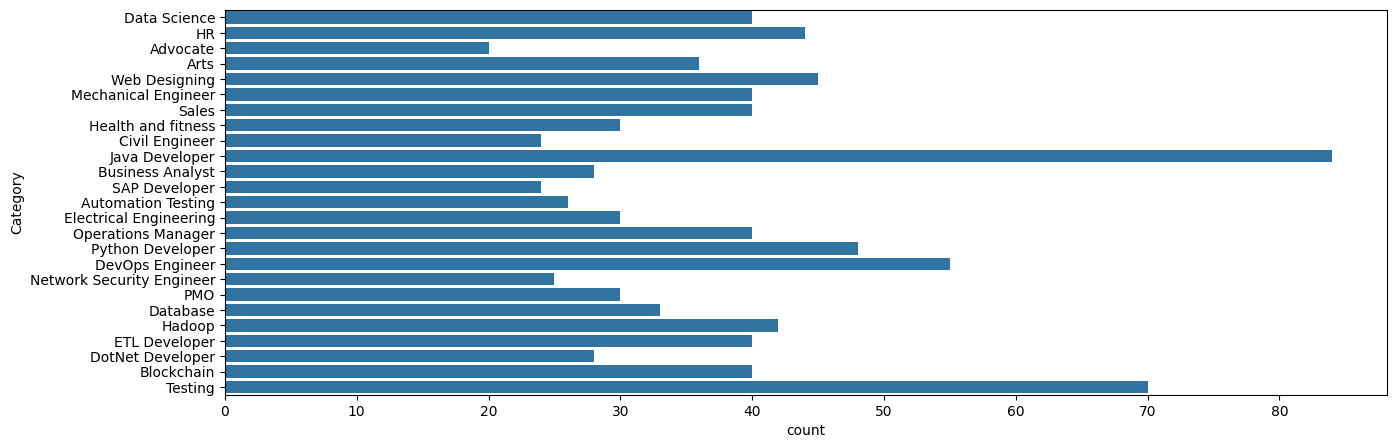

In [7]:
plt.figure(figsize=(15,5))
sns.countplot(dataset['Category'])
plt.show()

In [8]:
dataset['Category'].unique()

array(['Data Science', 'HR', 'Advocate', 'Arts', 'Web Designing',
       'Mechanical Engineer', 'Sales', 'Health and fitness',
       'Civil Engineer', 'Java Developer', 'Business Analyst',
       'SAP Developer', 'Automation Testing', 'Electrical Engineering',
       'Operations Manager', 'Python Developer', 'DevOps Engineer',
       'Network Security Engineer', 'PMO', 'Database', 'Hadoop',
       'ETL Developer', 'DotNet Developer', 'Blockchain', 'Testing'],
      dtype=object)

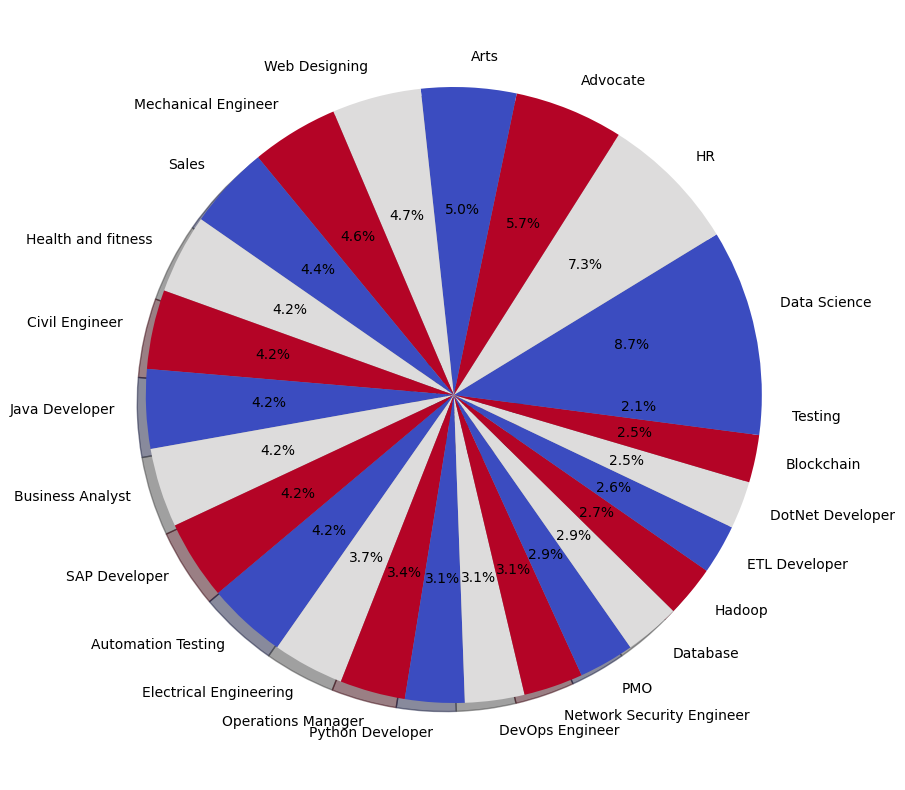

In [9]:
counts = dataset['Category'].value_counts()
labels = dataset['Category'].unique()

plt.figure(figsize=(15,10))
plt.pie(counts,labels=labels,autopct="%1.1f%%",shadow=True, colors =plt.cm.coolwarm(np.linspace(0,1,3)))
plt.show()

### Exploring Resume

In [10]:
dataset['Category'][0]

'Data Science'

In [11]:
dataset['Resume'][0]

'Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regression, SVM, NaÃ¯ve Bayes, KNN, Random Forest, Decision Trees, Boosting techniques, Cluster Analysis, Word Embedding, Sentiment Analysis, Natural Language processing, Dimensionality reduction, Topic Modelling (LDA, NMF), PCA & Neural Nets. * Database Visualizations: Mysql, SqlServer, Cassandra, Hbase, ElasticSearch D3.js, DC.js, Plotly, kibana, matplotlib, ggplot, Tableau. * Others: Regular Expression, HTML, CSS, Angular 6, Logstash, Kafka, Python Flask, Git, Docker, computer vision - Open CV and understanding of Deep learning.Education Details \r\n\r\nData Science Assurance Associate \r\n\r\nData Science Assurance Associate - Ernst & Young LLP\r\nSkill Details \r\nJAVASCRIPT- Exprience - 24 months\r\njQuery- Exprience - 24 months\r\nPython- Exprience - 24 monthsCompany Details \r\ncompany - Ernst & Young LLP\r\ndescription - Fraud Investigatio

### Balance Classes (Categories)

In [12]:
print("Original Category Distribution:")
print(dataset['Category'].value_counts())

# Get the Largest category size
max_size  =dataset['Category'].value_counts().max()

# Perform oversampling
balanced_dataset = dataset.groupby('Category').apply(lambda x: x.sample(max_size, replace=True)).reset_index(drop=True)

# dataset to avoid any order
dataset = balanced_dataset.sample(frac=1).reset_index(drop=True)

# check the balanced category distribution
print("\nBalanced Category Distribution (After Oversampling):")
print(dataset['Category'].value_counts())

Original Category Distribution:
Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Sales                        40
Data Science                 40
Mechanical Engineer          40
ETL Developer                40
Blockchain                   40
Operations Manager           40
Arts                         36
Database                     33
Health and fitness           30
PMO                          30
Electrical Engineering       30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
Civil Engineer               24
SAP Developer                24
Advocate                     20
Name: count, dtype: int64

Balanced Category Distribution (After Oversampling):
Category
Java Developer               84
Mechanical Engineer          84
Web De

C:\Users\SURENDRA\AppData\Local\Temp\ipykernel_16900\3182976093.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced_dataset = dataset.groupby('Category').apply(lambda x: x.sample(max_size, replace=True)).reset_index(drop=True)


### Cleaning Data
1.URLS,
2.hashtags,
3.mentions,
4.special leters,
5.punctuations:

In [13]:
import re
def cleanResume(txt):
    cleanTxt = re.sub(r'http\S+\s',' ',txt)
    cleanTxt = re.sub(r'RT|cc',' ',cleanTxt)
    cleanTxt = re.sub(r'#\S+',' ',cleanTxt)
    cleanTxt = re.sub(r'@\S+',' ',cleanTxt)
    cleanTxt = re.sub(r'[%s]'% re.escape("""#$%&'()*+,-./:;<=>?@[|]^_`{|}~"""),' ',cleanTxt)
    cleanTxt = re.sub(r'[^\x00-\x7f]',' ',cleanTxt)
    cleanTxt = re.sub(r'\s+',' ',cleanTxt)
    return cleanTxt

In [14]:
cleanResume("My #### #noorsaeed website like is this http://helloworld and access it @gmail.com")

'My website like is this and a ess it '

In [15]:
dataset['Resume']=dataset['Resume'].apply(lambda x: cleanResume(x))

In [16]:
dataset['Resume'][0]

'Computer Skills Languages And Script JSP Servlet HTML CSS Java Script Jquery Ajax Spring Hibernate Operating System Microsoft Windows 2003 XP Vista 7 8 Databases My SQL Concepts OOPS Core java Advance java Development Tool Eclipse Net beans IDE Web Server Apache Tomcat 7 0Education Details January 2007 H S C Amravati Maharashtra VidyaBharati college January 2005 S S C Amravati Maharashtra Holy Cross English School Java Developer Java Developer Kunal IT Services Pvt Ltd Skill Details ECLIPSE Exprience Less than 1 year months JAVA Exprience 14 months HIBERNATE Exprience Less than 1 year months SPRING Exprience Less than 1 year months jQuery Exprience Less than 1 year monthsCompany Details company Kunal IT Services Pvt Ltd description Currently Working As Java Developer In Winsol Solution Pvt Ltd From 1 July 2017 To Till Date Experience Of 2 Yrs As A Java Developer In Kunal IT Services Pvt Ltd '

### Words into categorical values

In [17]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [18]:
le.fit(dataset['Category'])
dataset['Category'] = le.transform(dataset['Category'])

In [19]:
print(dataset['Category'])

0       15
1       16
2       24
3       14
4       18
        ..
2095     3
2096     8
2097    21
2098    17
2099     9
Name: Category, Length: 2100, dtype: int64


In [20]:
dataset.Category.unique()

array([15, 16, 24, 14, 18, 12,  9, 17,  2,  6, 23, 22, 13, 21, 10, 20,  1,
       11,  7,  0, 19,  4,  3,  8,  5])

### Vactorization

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidataset = TfidfVectorizer(stop_words='english')

tfidataset.fit(dataset['Resume'])
requredTaxt = tfidataset.transform(dataset['Resume']) 

In [22]:
requredTaxt

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 368872 stored elements and shape (2100, 7351)>

### Splitting

In [23]:
from sklearn.model_selection import train_test_split
# x = dataset['Resume'] # features(text)
# y = dataset['Category'] # labels

In [24]:
x_train, x_test, y_train, y_test = train_test_split(requredTaxt,dataset['Category'], test_size=0.2, random_state=42)

In [25]:
x_train.shape

(1680, 7351)

In [26]:
x_test.shape

(420, 7351)

### Now let's train the model and print the classfication report:

In [27]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Ensure that X_train and X_test are dense if they are sparse
x_train = x_train.toarray() if hasattr(x_train, 'toarray') else x_train
x_test = x_test.toarray() if hasattr(x_test, 'toarray') else x_test

# 1. Train KNeighborsClassifier
knn_model = OneVsRestClassifier(KNeighborsClassifier())
knn_model.fit(x_train, y_train)
y_pred_knn = knn_model.predict(x_test)
print("\nKNeighborsClassifier Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_knn)}")
print(f"Classification Report:\n{classification_report(y_test, y_pred_knn)}")
# clf = OneVsRestClassifier(KNeighborsClassifier())
# clf.fit(x_train,y_train)
# ypred = clf.predict(x_test)
# print(accuracy_score(y_test,ypred))


KNeighborsClassifier Results:
Accuracy: 0.9976
Confusion Matrix:
[[25  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0 21  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0 13  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0 21  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0 16  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0 18  0  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0 13  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0 15  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0 14  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0 26  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0  0 13  0  0  0  0  0  

In [28]:
# 2. Train SVC
svc_model = OneVsRestClassifier(SVC())
svc_model.fit(x_train, y_train)
y_pred_svc = svc_model.predict(x_test)
print("\nSVC Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svc):.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_svc)}")
print(f"Classification Report:\n{classification_report(y_test, y_pred_svc)}")


SVC Results:
Accuracy: 1.0000
Confusion Matrix:
[[25  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0 21  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0 13  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0 21  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0 16  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0 19  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0 13  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0 15  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0 14  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0 26  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0  0 13  0  0  0  0  0  0  0  0  0  0  0 

In [29]:
# 3. Train RandomForestClassifier
rf_model = OneVsRestClassifier(RandomForestClassifier())
rf_model.fit(x_train, y_train)
y_pred_rf = rf_model.predict(x_test)
print("\nRandomForestClassifier Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_rf)}")
print(f"Classification Report:\n{classification_report(y_test, y_pred_rf)}")


RandomForestClassifier Results:
Accuracy: 1.0000
Confusion Matrix:
[[25  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0 21  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0 13  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0 21  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0 16  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0 19  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0 13  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0 15  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0 14  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0 26  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0  0 13  0  0  0  0  0

### Save File

In [30]:
import pickle
pickle.dump(tfidataset,open('tfidf.pkl','wb'))
pickle.dump(svc_model, open('clf.pkl', 'wb'))
pickle.dump(le, open("encoder.pkl",'wb'))

### Prediction System

In [31]:
# Function to predict the category of a resume
def pred(input_resume):
    # Preprocess the input text (e.g., cleaning, etc.)
    cleaned_text = cleanResume(input_resume) 

    # Vectorize the cleaned text using the same TF-IDF vectorizer used during training
    vectorized_text = tfidataset.transform([cleaned_text])
    
    # Convert sparse matrix to dense
    vectorized_text = vectorized_text.toarray()

    # Prediction
    predicted_category = svc_model.predict(vectorized_text)

    # get name of predicted category
    predicted_category_name = le.inverse_transform(predicted_category)

    return predicted_category_name[0]  # Return the category name

In [32]:
myresume = """I am a data Scientist Specializing in machine 
learning,depp learning, and computer vision. With
a strong background in mathematics, statistics,
and programming, I am passionate about
uncovering hidden patterns and insights in data.
I have extensive experience in developing
predictive models, implementing deep learning
algorithms and designing computer vision
system. My technical skills include proficiency in 
Python, Sklearn, TensorFlow, and PyTorch.
What sets me apart is my ability to effectively
communicate complex concepts to diverse
audiences. I excel in translating technical insights
into actionable recommendations that drive
informed decision-making.
If you're looking for a dedicated and versatile data
scientist to collaborate on impactful projects,I am 
eage to contribute my expertise. let's harness the 
power of data together to unlock new possibilities
and shape a better future.
Contact & Sources
Email: surndravarma336@gmail.com
Phone: 6301506109
Github:https://github.com/surendra7438
Linkdin:https://www.linkedin.com/in/surendara-varma/
ABOUT ME
WORK EXPERIENCE
SKILLES
LANGUAGES
English
Hindi
Telugu
I am a versatile data scientist with expertise in a wide
range of project, including machine learning, recommendation system, deep learning, and computer
vision. Throughout my career, I have successfully
developed and deployed various machine learning models 
to slove complex problem and drive data-driven
decision-making
Machine Learnine
Deep Learning
Computer Vision
Recommendation Systems
Data Visulization
Programming Language(Python, SQL)
Data Preprocessing and Feature Engineering
Model Evaluation and Deployment
Statisical Analysis
Communication and Collaboration
"""
pred(myresume)

'Data Science'

In [33]:
import os

print("Current Folder:")
print(os.getcwd())

print("\nFiles:")
for file in os.listdir():
    print(file)

Current Folder:
d:\ML project

Files:
clf.pkl
encoder.pkl
Resume Screening System.ipynb
Resume Screening.csv
resume_screening_system.html
tfidf.pkl


In [34]:
import pickle
import os

# Show files in current directory
print("Available Files:")
print(os.listdir())

# Load classifier
clf = pickle.load(open('clf.pkl', 'rb'))

# Possible TF-IDF filenames
possible_files = [
    'tfidataset.pkl',
    'tfidf.pkl',
    'tfidf_vectorizer.pkl',
    'vectorizer.pkl'
]

tfidataset = None

for file in possible_files:
    if os.path.exists(file):
        tfidataset = pickle.load(open(file, 'rb'))
        print(f"Loaded vectorizer from: {file}")
        break

if tfidataset is None:
    print("ERROR: No TF-IDF pickle file found!")
    print("Available files are:", os.listdir())
else:
    # Clean resume
    cleaned_resume = cleanResume(myresume)

    # Transform resume
    input_feature = tfidataset.transform([cleaned_resume])

    # Convert sparse matrix to dense (Fix for SVC)
    input_feature = input_feature.toarray()

    # Predict
    prediction_id = clf.predict(input_feature)[0]

    # Category mapping
    category_mapping = {
        15:"Java Developer",
        23:"Testing",
        8:"DeVOps Engineer",
        20:"Python Developer",
        24:"Web Designing",
        12:"HR",
        13:"Hadoop",
        3:"Blockchain",
        10:"ETL Developer",
        18:"Operations Manager",
        6:"Data Science",
        22:"Sales",
        16:"Mechanical Engineer",
        1:"Arts",
        7:"Database",
        11:"Electrical Engineering",
        14:"Health and fitness",
        19:"PMO",
        4:"Business Analyst",
        9:"DotNet Developer",
        2:"Automation Testing",
        17:"Network Security Engineer",
        21:"SAP Developer",
        5:"Civil Engineer",
        0:"Advocate"
    }

    print("Predicted Category:",
          category_mapping.get(prediction_id, "Unknown"))

Available Files:
['clf.pkl', 'encoder.pkl', 'Resume Screening System.ipynb', 'Resume Screening.csv', 'resume_screening_system.html', 'tfidf.pkl']
Loaded vectorizer from: tfidf.pkl
Predicted Category: Data Science
